# Data Structures and Algorithms

<p style="font-size:1.25em; color:#555; margin-top:0;">A hands-on course: ideas, Python code, pictures, measurements</p>

<p style="color:#777;">Seven notebooks that take you from "what does O(n) mean?" to writing dynamic programming solutions, with every structure drawn and every claim about speed measured.</p>

## Who this is for

You can write basic Python: loops, functions, lists and dicts. That is all. No computer science background is assumed.
Every idea is introduced three times: as a **picture**, as **code you can read in one screen**, and as a **measurement** on your own machine.

By the end you will be able to:

* read and write Big-O estimates for code you meet, and confirm them with a timing plot;
* choose the right container for a job (list, deque, dict, set, heap, tree, graph) and say why;
* implement the classic algorithms from memory: binary search, merge sort, quicksort, BFS, DFS, Dijkstra;
* recognise a dynamic programming problem and build the table for it.

## Course map

| # | Notebook | What you learn | Tools introduced |
|---|----------|----------------|------------------|
| 0 | [Start Here](00_Start_Here.ipynb) | Setup check, the toolkit, cost cheat sheet, glossary | `time_it`, `growth_plot`, drawing helpers |
| 1 | [Complexity and Big-O](01_Complexity_and_Big_O.ipynb) | Counting steps, Big-O rules, timing plots, best/worst/amortised cost | `growth_plot`, Binary Search Stepper |
| 2 | [Arrays, Linked Lists, Stacks and Queues](02_Arrays_Linked_Lists_Stacks_Queues.ipynb) | Arrays vs linked lists, dynamic array growth, stacks, queues, call stack | `draw_array`, `draw_linked_list`, `collections.deque` |
| 3 | [Hash Tables and Sets](03_Hash_Tables_and_Sets.ipynb) | Hashing, buckets, collisions, load factor, why dict and set are fast | Hash Table Lab, `collections.Counter` |
| 4 | [Recursion, Searching and Sorting](04_Recursion_Searching_and_Sorting.ipynb) | Recursion, divide and conquer, binary search, four sorting algorithms compared | Sorting Visualiser, `bisect` |
| 5 | [Trees and Heaps](05_Trees_and_Heaps.ipynb) | Binary search trees, balance, traversals, heaps and priority queues | `draw_tree`, BST Builder, `heapq` |
| 6 | [Graphs](06_Graphs.ipynb) | Adjacency lists, BFS, DFS, grid mazes, Dijkstra, topological order | `draw_graph`, `draw_grid`, Graph Explorer |
| 7 | [Dynamic Programming](07_Dynamic_Programming.ipynb) | Overlapping subproblems, memoisation vs tabulation, coin change, edit distance, knapsack | `draw_table`, Coin Change Lab, Edit Distance Lab |

**Suggested path:** in order. Modules 1 to 3 are the vocabulary, 4 and 5 the classic algorithms, 6 and 7 the ones interviews and real systems lean on.

## How to use each module

Every module follows the same rhythm:

1. **Learning objectives** at the top say what you should be able to do afterwards.
2. **Theory** in short sections, each followed by code that demonstrates it and usually a picture of the structure.
3. **Measurements.** Where a claim is about speed, a cell times it on your machine. Do not take Big-O on faith.
4. **A lab**: an interactive widget where you drive the algorithm yourself.
5. **Try it yourself** exercises with solutions behind a *Solutions* toggle. Attempt first.
6. **Checkpoint quiz** and **key takeaways**.

Run every cell (`Shift+Enter`), then change something and run it again. Timing cells take a few seconds; the numbers will differ on your machine, the shapes will not.

## Environment check

Run this first. It confirms the `data_structures_algorithms` kernel has everything the course needs and that the helper package imports.

Python      3.13.11
Interpreter /Users/indranandjha/Developer/personal/data_structures_algorithms/.venv/bin/python3

numpy       2.5.2
matplotlib  3.11.1
ipywidgets  8.1.9

dsalab imported. time_it(sum, range(10**6)) = 0.0059 s


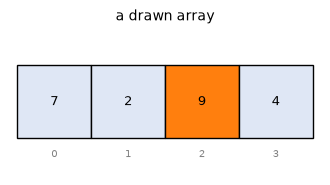

In [1]:
import sys
import numpy, matplotlib, ipywidgets

print(f"Python      {sys.version.split()[0]}")
print(f"Interpreter {sys.executable}")
print()
for name, mod in [("numpy", numpy), ("matplotlib", matplotlib), ("ipywidgets", ipywidgets)]:
    print(f"{name:<12}{mod.__version__}")

from dsalab import draw_array, time_it
print("\ndsalab imported. time_it(sum, range(10**6)) =", f"{time_it(sum, range(10**6)):.4f} s")
draw_array([7, 2, 9, 4], highlight={2: "tab:orange"}, title="a drawn array")

## Your toolkit

The `dsalab` folder next to these notebooks holds three kinds of helpers. (The import works because Jupyter starts each notebook's kernel in the notebook's own folder.)

| Helper | What it does |
|--------|--------------|
| `time_it(fn, *args)` | Best-of-three wall-clock time of a call, in seconds. |
| `growth_plot({label: fn}, sizes)` | Times each `fn(n)` for every `n` in sizes and plots the curves on log axes. This is how every Big-O claim in the course is checked. |
| `draw_array`, `draw_linked_list`, `draw_tree`, `draw_graph`, `draw_grid`, `draw_table` | Pictures of the structures, with optional highlighting. |
| `quiz(module)` | The checkpoint quiz. |

And seven labs:

| Lab | Module | What you do |
|-----|--------|-------------|
| Binary Search Stepper | 1 | Step through the comparisons and watch the range shrink. |
| Hash Table Lab | 3 | Pour keys into buckets, watch collisions, switch on resizing. |
| Sorting Visualiser | 4 | Play four sorting algorithms on the same input and count their steps. |
| BST Builder | 5 | Insert keys, search, and see why insertion order decides the height. |
| Graph Explorer | 6 | Step through BFS and DFS with the queue or stack shown. |
| Coin Change Lab | 7 | Build the DP table and watch greedy fail. |
| Edit Distance Lab | 7 | Type two words and see the table and the path through it. |

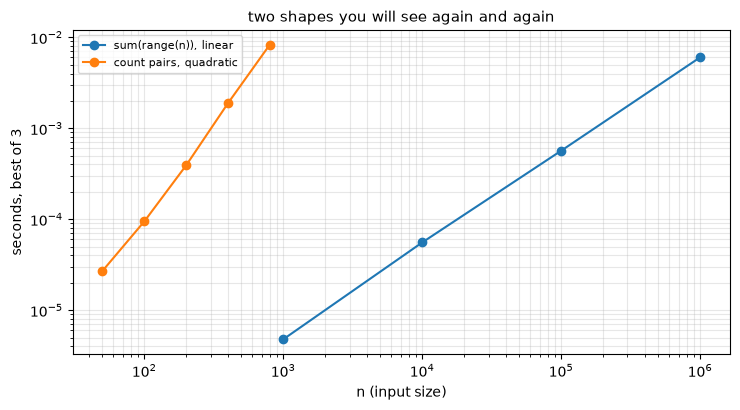

In [2]:
from dsalab import growth_plot

# A first timing plot. Both curves are straight lines on log axes; the slope is the exponent.
growth_plot(
    {"sum(range(n)), linear": lambda n: sum(range(n)),
     "count pairs, quadratic": lambda n: sum(1 for i in range(n) for j in range(n) if i < j)},
    {"sum(range(n)), linear": [10**3, 10**4, 10**5, 10**6],
     "count pairs, quadratic": [50, 100, 200, 400, 800]},
    title="two shapes you will see again and again",
)

## Cost cheat sheet for Python's built-ins

Keep this open. "Amortised" means occasional slow operations averaged over many fast ones.

| Structure | Operation | Cost |
|-----------|-----------|------|
| `list` | index `a[i]`, `a[i] = x`, `append`, `pop()` | O(1) (append amortised) |
| `list` | `insert(0, x)`, `pop(0)`, `x in a`, `remove` | O(n) |
| `list` | `sorted(a)`, `a.sort()` | O(n log n) |
| `deque` | `append`, `appendleft`, `pop`, `popleft` | O(1) |
| `dict`, `set` | `d[k]`, `k in d`, `d[k] = v`, `add`, `remove` | O(1) average |
| `heapq` | `heappush`, `heappop` | O(log n) |
| `heapq` | `heap[0]` (peek min) | O(1) |
| `bisect` | find position in a sorted list | O(log n) (but inserting is O(n)) |
| `str` | `s + t`, slicing | O(len) |

## Big-O cheat sheet

| Class | Name | Typical example | n = 1,000,000 |
|-------|------|-----------------|---------------|
| O(1) | constant | index into a list, dict lookup | 1 |
| O(log n) | logarithmic | binary search, heap push | 20 |
| O(n) | linear | scan a list, sum | 1,000,000 |
| O(n log n) | linearithmic | good sorting | 20,000,000 |
| O(n^2) | quadratic | nested loops over the input, bubble sort | 10^12 |
| O(2^n) | exponential | trying every subset | hopeless past n = 40 |

## Glossary

* **Amortised cost**: the average cost per operation over a long sequence, even if a few operations are expensive.
* **Big-O**: an upper bound on how running time (or memory) grows with input size, ignoring constants and lower-order terms.
* **Divide and conquer**: split the problem, solve the parts recursively, combine.
* **Dynamic programming**: solve overlapping subproblems once and store the answers.
* **Hash function**: maps a key to a bucket index; a good one spreads keys evenly.
* **Heap**: a tree stored in an array where each parent is smaller (min-heap) than its children.
* **Invariant**: something that stays true throughout an algorithm; the way to convince yourself it is correct.
* **Recursion**: a function that calls itself on a smaller input, stopping at a base case.
* **Stable sort**: equal items keep their original relative order.
* **Traversal**: visiting every node of a tree or graph in a systematic order.

[Course Index](00_Start_Here.ipynb)  |  [Next: Module 1: Complexity and Big-O](01_Complexity_and_Big_O.ipynb)